In [56]:
from sklearn import datasets


dataset=datasets.load_iris()


x=dataset.data
x.shape

(150, 4)

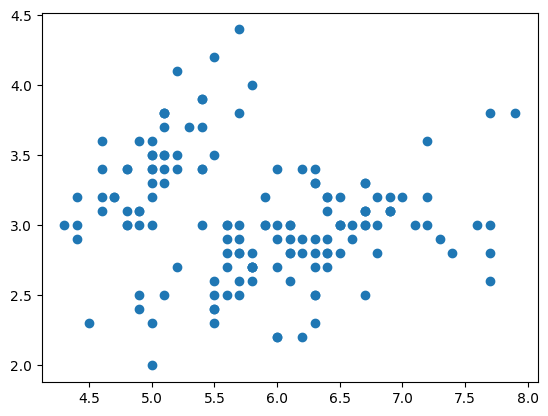

In [57]:
import matplotlib.pyplot as plt

plt.scatter(x[:,0],x[:,1])

In [58]:
import random
import numpy as np

class KMeans:
    def __init__(self,n_clusters):
        self.n_clusters=n_clusters
    def init_centroids(self,x):
        return random.sample(list(x),self.n_clusters)
    def Euc_distance(self,a,b):
        return np.sqrt(np.sum((a-b)**2))
    def fit(self,x,n_iter=10):
        centroids=self.init_centroids(x)
        for _ in range(n_iter):
            clusters={i:[] for i in range(self.n_clusters)}
            for point in x:
                distances=[self.Euc_distance(point,centroid) for centroid in centroids]
                cluster_assigned=np.argmin(distances)
                clusters[cluster_assigned].append(point)
            for i in range(self.n_clusters):
                centroids[i]=np.mean(clusters[i],axis=0)
        self.centroids=centroids
        return centroids,clusters

      
        
        




In [59]:
kmeans=KMeans(3)
centroids,clusters=kmeans.fit(x,50)


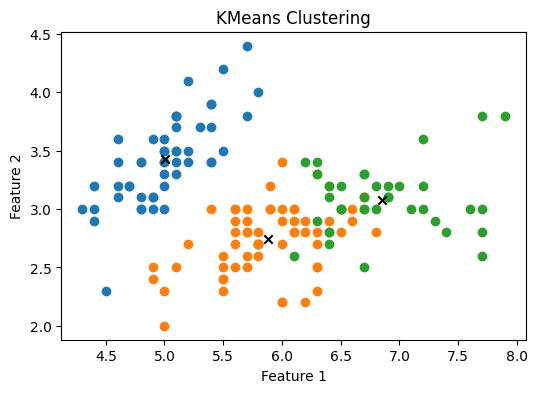

In [63]:
plt.figure(figsize=(6,4))
for i in range(3):
    plt.scatter(np.array(clusters[i])[:,0],np.array(clusters[i])[:,1])
plt.scatter(np.array(centroids)[:,0],np.array(centroids)[:,1],color='black',marker='x')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustering")
plt.show()

# Built Sklearn

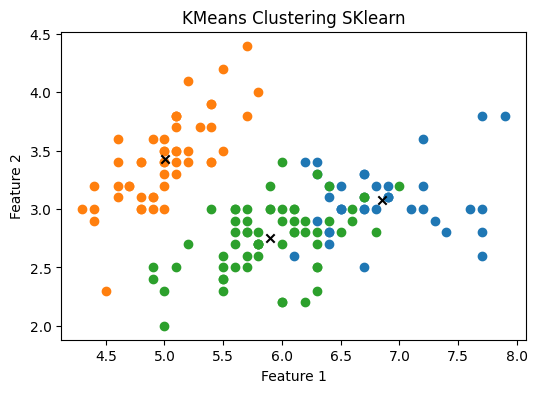

In [54]:
from sklearn.cluster import KMeans as skKMeans

kmeans=skKMeans(n_clusters=3,max_iter=50)
kmeans.fit(x)
clusters=kmeans.predict(x)

plt.figure(figsize=(6,4))
for i in range(3):
    plt.scatter(x[clusters==i][:,0],x[clusters==i][:,1])
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],color='black',marker='x')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustering SKlearn")
plt.show()
